In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/')

import Stellar_sim_funcs as SSF

import os 
import glob

dir = '/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Plots/T_dep/'

W0619 07:03:08.039297 3805016 platform_util.cc:218] unable to create StreamExecutor for CUDA:0: CUDA error: : CUDA_ERROR_UNKNOWN: unknown error


In [8]:
data_files = glob.glob(os.path.join(dir, '*data*.csv'))
print(data_files)

data = pd.read_csv(data_files[1])



['/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Plots/T_dep/t_dep_lf_data_m5_R0.19.csv', '/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Plots/T_dep/t_dep_lf_data_m10_R1.csv', '/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Plots/T_dep/t_dep_lf_data_m10_R0.19.csv', '/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/Plots/T_dep/t_dep_lf_data_m2_R0.19.csv']


In [9]:
data.head()


,time_Gyr,particle_0_kinetic_energy_J,particle_0_potential_energy_J,particle_0_ang_mom_kg_m2_s,particle_0_x_kpc,particle_0_y_kpc,particle_0_z_kpc,particle_0_v_x_kms,particle_0_v_y_kms,particle_0_v_z_kms,...,particle_3_v_z_kms,particle_4_kinetic_energy_J,particle_4_potential_energy_J,particle_4_ang_mom_kg_m2_s,particle_4_x_kpc,particle_4_y_kpc,particle_4_z_kpc,particle_4_v_x_kms,particle_4_v_y_kms,particle_4_v_z_kms
0,0.000000,1529.069111,-6410.020558,8.193796,-0.842951,-0.003507,0.530362,5.506859,-11.968545,8.673378,...,-10.765604,1527.458807,-6449.243960,8.084100,-0.082760,-0.849839,-0.487262,-10.680489,6.533065,-9.580357
1,0.003764,1528.987904,-6409.939131,8.193581,-0.820210,-0.049524,0.562730,6.309457,-11.942590,8.145620,...,-10.381585,1527.466666,-6449.253933,8.084123,-0.123672,-0.823101,-0.523174,-10.578353,7.360880,-9.080430
2,0.007527,1528.820379,-6409.200238,8.193143,-0.794426,-0.095355,0.593009,7.088227,-11.871986,7.587593,...,-9.960526,1527.465230,-6448.409393,8.084133,-0.164114,-0.793230,-0.557097,-10.436022,8.160325,-8.546147
3,0.011291,1528.599188,-6408.359850,8.192574,-0.765697,-0.140829,0.621085,7.840306,-11.757180,7.001493,...,-9.504102,1527.428314,-6447.607585,8.084079,-0.203932,-0.760344,-0.588900,-10.254165,8.928064,-7.979590
4,0.015054,1528.364783,-6407.478816,8.191988,-0.734129,-0.185778,0.646857,8.563000,-11.598807,6.389613,...,-9.014061,1527.341603,-6446.794505,8.083944,-0.242976,-0.724569,-0.618466,-10.033681,9.661029,-7.382935


In [10]:
time_gyr = data['time_Gyr']

no_particles = int((len(data.columns) - 1) / 9)  # Subtract 1 for the time column
print(f'Number of particles: {no_particles}')

kinetic_energy = np.zeros((no_particles, len(time_gyr)))
potential_energy = np.zeros((no_particles, len(time_gyr)))
angular_momentum = np.zeros((no_particles, len(time_gyr)))

x = np.zeros((no_particles, len(time_gyr)))
y = np.zeros((no_particles, len(time_gyr)))
z = np.zeros((no_particles, len(time_gyr)))

vx = np.zeros((no_particles, len(time_gyr)))
vy = np.zeros((no_particles, len(time_gyr)))
vz = np.zeros((no_particles, len(time_gyr)))

for particle in range(no_particles):

    kinetic_energy[particle, :] = data[f'particle_{particle}_kinetic_energy_J']
    potential_energy[particle, :] = data[f'particle_{particle}_potential_energy_J']
    angular_momentum[particle, :] = data[f'particle_{particle}_ang_mom_kg_m2_s']

    x[particle, :] = data[f'particle_{particle}_x_kpc']
    y[particle, :] = data[f'particle_{particle}_y_kpc']
    z[particle, :] = data[f'particle_{particle}_z_kpc']

    vx[particle, :] = data[f'particle_{particle}_v_x_kms']
    vy[particle, :] = data[f'particle_{particle}_v_y_kms']
    vz[particle, :] = data[f'particle_{particle}_v_z_kms']



positions_all = np.stack((x, y, z), axis=-1)  # shape (N, T, 3)

Number of particles: 5


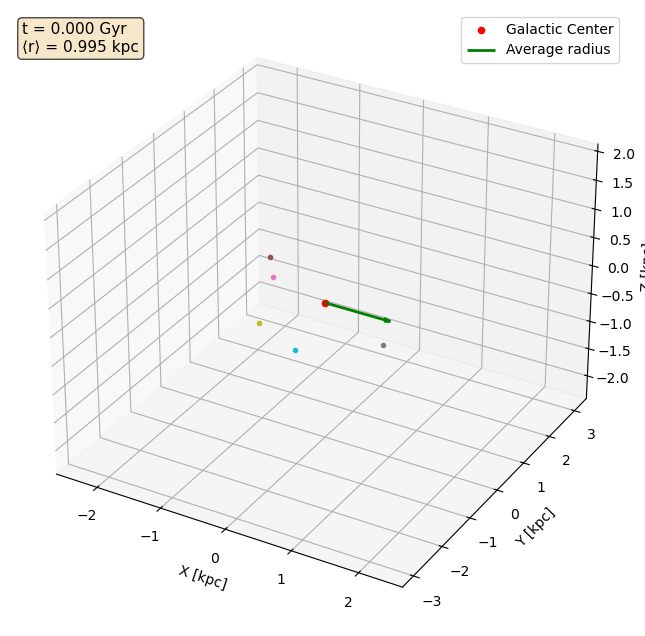

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib 
matplotlib.rcParams['animation.embed_limit'] = 500  
from IPython.display import HTML

positions_all = np.stack((x, y, z), axis=-1)  # shape (N, T, 3)

N, T, _ = positions_all.shape
dt_Gyr = time_gyr[1] - time_gyr[0]

# Average radius (mean distance from the center) at each frame
r_all = np.linalg.norm(positions_all, axis=-1)  # (N, T)
r_average = r_all.mean(axis=0)                   # (T,)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

# Fix axis limits so the view doesn't jump
xyz_min = positions_all.reshape(-1, 3).min(axis=0) 
xyz_max = positions_all.reshape(-1, 3).max(axis=0) 
ax.set_xlim(xyz_min[0], xyz_max[0])
ax.set_ylim(xyz_min[1], xyz_max[1])
ax.set_zlim(xyz_min[2], xyz_max[2])
ax.set_xlabel('X [kpc]'); ax.set_ylabel('Y [kpc]'); ax.set_zlabel('Z [kpc]')

# One trail line + one head point per particle
trails = [ax.plot([], [], [], lw=0.8)[0] for _ in range(N)]
heads  = [ax.plot([], [], [], 'o', ms=3)[0] for _ in range(N)]

# Average-radius arrow: fixed +X direction, length = r_average[frame].
# quiver returns a Line3DCollection that can't be updated in place, so we
# keep a handle and replace it each frame.
arrow_dir = np.array([1.0, 0.0, 0.0])  # fixed direction (+X)
arrow = [ax.quiver(0, 0, 0, *(arrow_dir * r_average[0]),
                   color='green', lw=2, arrow_length_ratio=0.1,
                   label='Average radius')]

# Time readout
time_text = ax.text2D(0.02, 0.98, '', transform=ax.transAxes,
                      verticalalignment='top', fontsize=11,
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax.legend(loc='upper right')

trail_len = 50  # frames of history to draw; set to T for full trail

def update(frame):
    start = max(0, frame - trail_len)
    for i in range(N):
        seg = positions_all[i, start:frame+1] 
        trails[i].set_data(seg[:, 0], seg[:, 1])
        trails[i].set_3d_properties(seg[:, 2])
        p = positions_all[i, frame]
        heads[i].set_data([p[0]], [p[1]])
        heads[i].set_3d_properties([p[2]])
    # Redraw the average-radius arrow with the current length
    arrow[0].remove()
    vec = arrow_dir * r_average[frame]
    arrow[0] = ax.quiver(0, 0, 0, *vec, color='green', lw=2,
                         arrow_length_ratio=0.1)
    time_text.set_text(f't = {frame * dt_Gyr:.3f} Gyr\n'
                       f'⟨r⟩ = {r_average[frame]:.3f} kpc')
    return trails + heads + [arrow[0], time_text]

anim = FuncAnimation(fig, update, frames=T, interval=40, blit=False)
HTML(anim.to_jshtml())   
anim.save('orbits_m_10.mp4', fps=20, dpi=150)


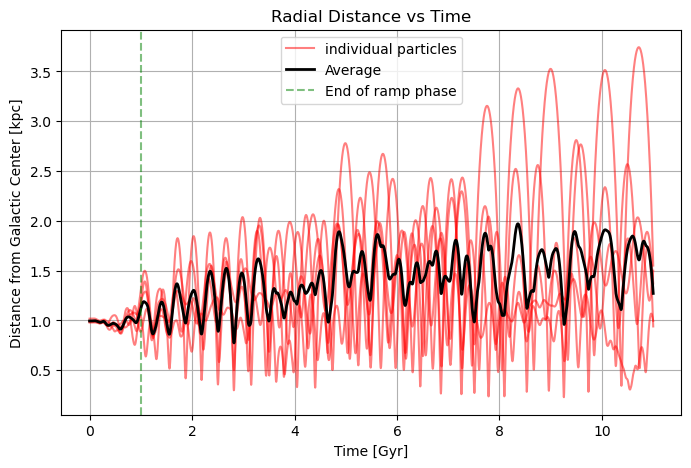

In [ ]:
r_all = np.linalg.norm(positions_all, axis=-1)  # shape (N, T)

r_average = r_all.mean(axis=0)

plt.figure(figsize=(8, 5))
for i in range(N-1):
    plt.plot(time_gyr, r_all[i], color='red', alpha=0.5)
plt.plot(time_gyr, r_all[-1], label = 'individual particles', color='red', alpha=0.5)
plt.plot(time_gyr, r_average, label='Average', color='black', linewidth=2)
plt.xlabel('Time [Gyr]')
#plt.axvline(x=1, color='green', linestyle='--', label='End of ramp phase', alpha = 0.5)
plt.ylabel('Distance from Galactic Center [kpc]')
plt.title('Radial Distance vs Time')
plt.legend()
plt.grid()
plt.show()


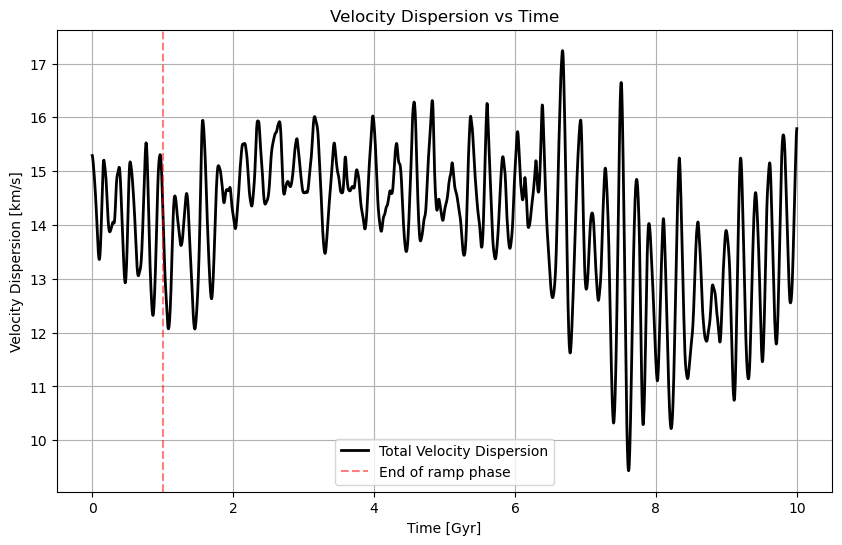

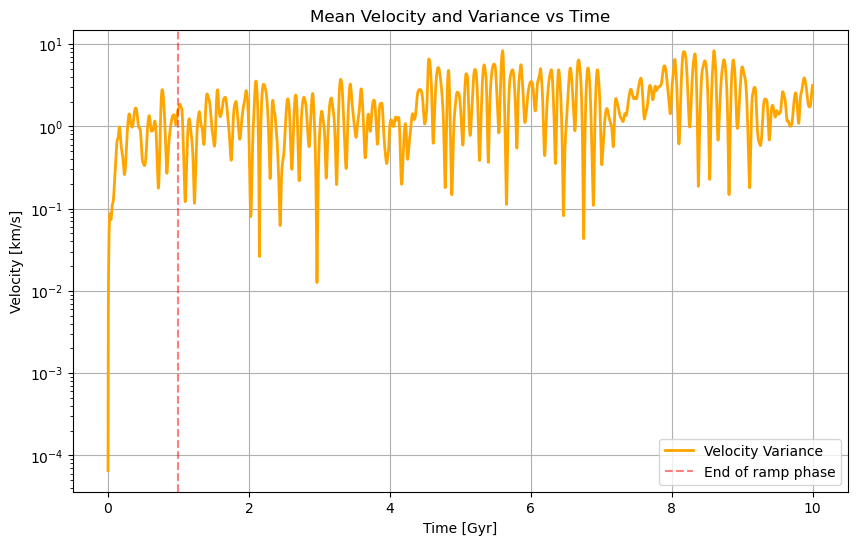

In [49]:
plt.figure(figsize=(10, 6))

vr, vtheta, vphi = SSF.Cartesian_to_sph_vel_np(x, y, z, vx, vy, vz)


velocity_disp_x = np.std(vx, axis=0)
velocity_disp_y = np.std(vy, axis=0)
velocity_disp_z = np.std(vz, axis=0)

velocity_disp_tot = np.sqrt(velocity_disp_x**2 + velocity_disp_y**2 + velocity_disp_z**2)


plt.plot(time_gyr, velocity_disp_tot, label='Total Velocity Dispersion', color='black', linewidth=2)
plt.xlabel('Time [Gyr]')
plt.axvline(x=1, color='red', linestyle='--', label='End of ramp phase', alpha = 0.5)
plt.ylabel('Velocity Dispersion [km/s]')
plt.title('Velocity Dispersion vs Time')
plt.legend()
plt.grid()
plt.show()


variance_v = np.var(np.sqrt(vx**2 + vy**2 + vz**2), axis=0)

plt.figure(figsize=(10, 6))
plt.plot(time_gyr, variance_v, label='Velocity Variance', color='orange', linewidth=2)
plt.xlabel('Time [Gyr]')
plt.axvline(x=1, color='red', linestyle='--', label='End of ramp phase', alpha = 0.5)
plt.ylabel('Velocity [km/s]')
plt.title('Mean Velocity and Variance vs Time')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

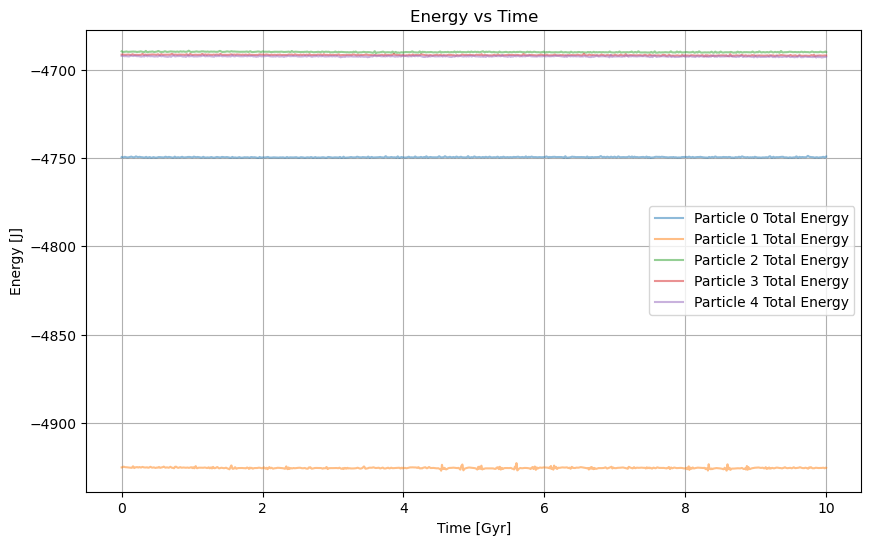

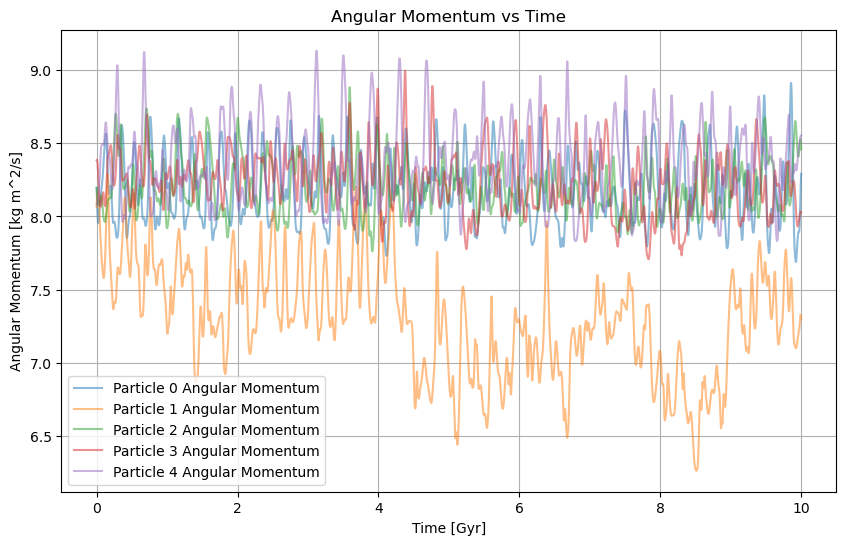

In [50]:
plt.figure(figsize=(10, 6))

for i in range(N):
    plt.plot(time_gyr, kinetic_energy[i] + potential_energy[i], label=f'Particle {i} Total Energy', alpha=0.5)

plt.xlabel('Time [Gyr]')
plt.ylabel('Energy [J]')
plt.title('Energy vs Time')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))

for i in range(N):
    plt.plot(time_gyr, angular_momentum[i], label=f'Particle {i} Angular Momentum', alpha=0.5)
plt.xlabel('Time [Gyr]')
plt.ylabel('Angular Momentum [kg m^2/s]')
plt.title('Angular Momentum vs Time')
plt.legend()
plt.grid()
plt.show()

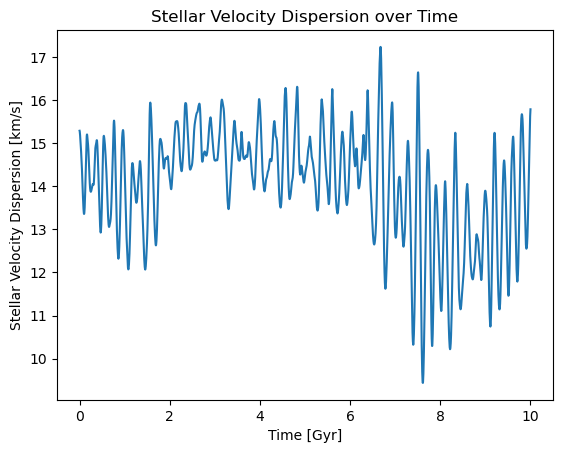

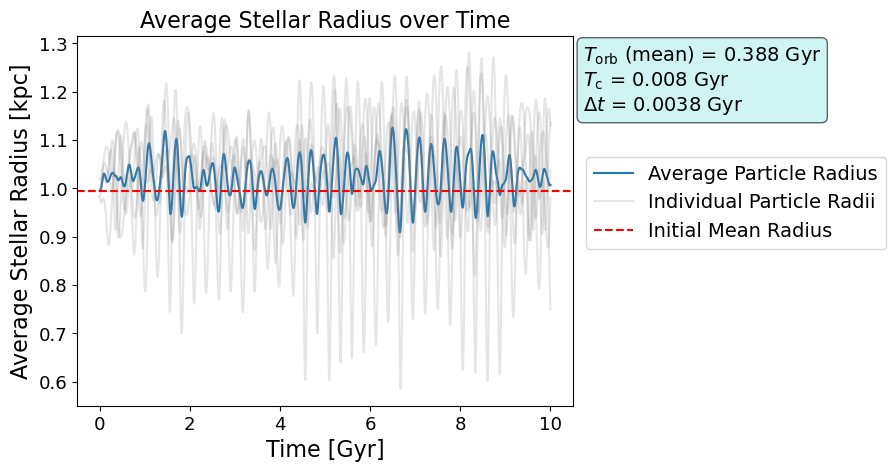

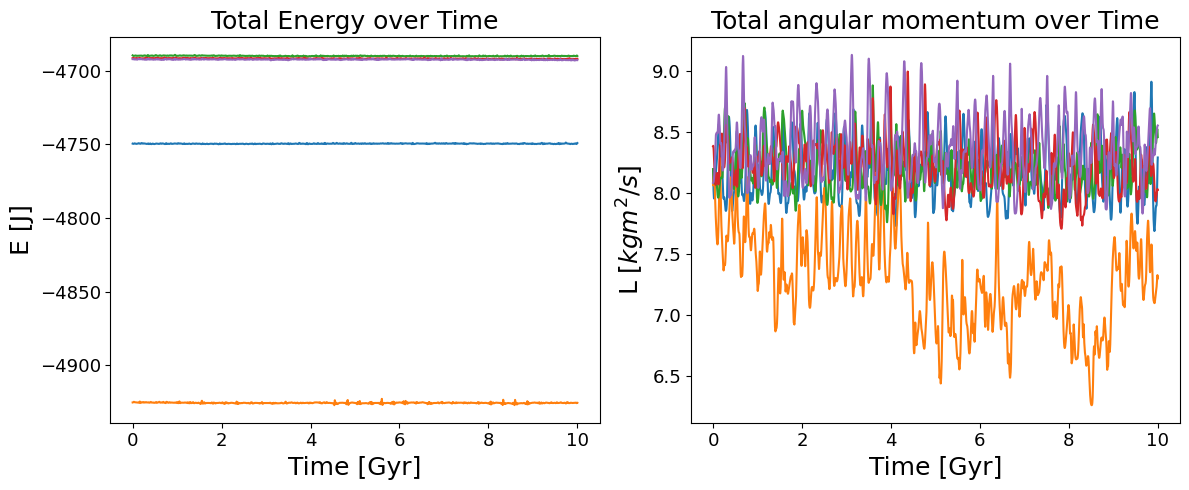

In [51]:
# --- Stellar velocity dispersion over time ---
# std across particles (axis=0) at each timestep -> shape (T,)
stellar_v_disp = np.sqrt(
    np.std(vx, axis=0)**2 +
    np.std(vy, axis=0)**2 +
    np.std(vz, axis=0)**2
)

plt.plot(time_gyr, stellar_v_disp)
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

# --- Average stellar radius over time ---
plt.plot(time_gyr, r_average, label='Average Particle Radius')
for particle in range(N - 1):
    plt.plot(time_gyr, r_all[particle, :], alpha=0.2, color='gray')
plt.plot(time_gyr, r_all[-1, :], alpha=0.2, color='gray', label='Individual Particle Radii')
init_r_mean = r_average[0]
plt.axhline(init_r_mean, color='r', linestyle='--', label='Initial Mean Radius')
plt.xlabel('Time [Gyr]', fontsize=16)
plt.ylabel('Average Stellar Radius [kpc]', fontsize=16)
plt.title('Average Stellar Radius over Time', fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# --- Timescale diagnostics ---
# Data are already in physical units (kpc, km/s, Gyr), so no sim.u conversions.
# 1 kpc/(km/s) expressed in Gyr:
KPC_PER_KMS_TO_GYR = 0.977792

v0 = np.sqrt(vx[:, 0]**2 + vy[:, 0]**2 + vz[:, 0]**2)  # km/s, initial speeds
r0 = r_all[:, 0]                                        # kpc, initial radii
mean_T_orb = float(np.mean(2 * np.pi * r0 / v0) * KPC_PER_KMS_TO_GYR)

# NOTE: T_c (de Broglie crossing) and the beat-time band need the axion mass
# (sim.m22) and eigen-energies (sim.eigen_energies), which aren't available
# from the CSV data alone, so they're omitted here.
# lambda_db_kpc = 19.15 / (sim.m22 * v0)
# T_c = lambda_db_kpc / v0 * KPC_PER_KMS_TO_GYR
# E = np.array(sim.eigen_energies)
# T_beat = 2 * np.pi / np.abs(E[:, None] - E[None, :]) * sim.u.to_Gyr
T_c = 0.008
info = (
    f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
    f"$T_{{\\rm c}}$ = {T_c:.3f} Gyr\n"
    f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
)

plt.text(1.02, 0.98, info, transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=14,
         bbox=dict(boxstyle='round', facecolor='paleturquoise', alpha=0.6))

plt.legend(bbox_to_anchor=(1.65, 0.7), fontsize=14)
plt.show()

# --- Total energy and angular momentum ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(N):
    ax[0].plot(time_gyr, kinetic_energy[particle] + potential_energy[particle], label='Total Energy')
ax[0].set_xlabel('Time [Gyr]', fontsize=18)
ax[0].set_ylabel('E [J]', fontsize=18)
ax[0].set_title('Total Energy over Time', fontsize=18)

for particle in range(N):
    ax[1].plot(time_gyr, angular_momentum[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]', fontsize=18)
ax[1].set_ylabel(r'L [$kg m^2/s$]', fontsize=18)
ax[1].set_title('Total angular momentum over Time', fontsize=18)

ax[0].tick_params(axis='both', which='major', labelsize=13)
ax[1].tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.show()


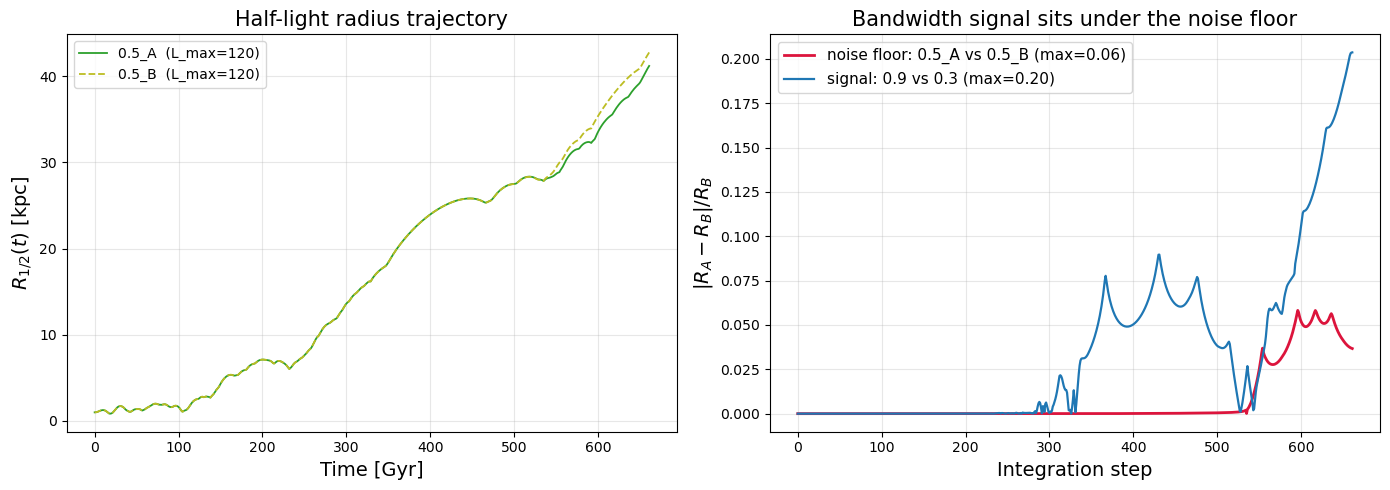

In [8]:
# --- Determinism check: bandwidth comparison vs run-to-run noise floor ---
# Loads determinism_check_results.npz (R_half(t) in sim units, R_0 = 1).
# 0.5_A and 0.5_B share an identical config, so their difference is the
# nondeterminism floor (multi-GPU + complex64 reductions amplified by chaos).
import jaxsp as jsp

m22 = 5
u = jsp.set_schroedinger_units(m22)


det = np.load('/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/'
              'determinism_check_results.npz', allow_pickle=True)

det_labels = list(det['labels'])
det_Lmax = {l: int(L) for l, L in zip(det_labels, det['Lmax'])}
r_det = {l: det[f'r_{l}'] for l in det_labels}

n_steps = len(r_det['truth_1.0'])
step = np.arange(n_steps)            # x-axis in integration steps (no unit conv in npz)

def rel(a, b):
    return np.abs(a - b) / np.abs(b)

colors = {'truth_1.0': 'black', '0.9': 'tab:blue',
          '0.5_A': 'tab:green', '0.5_B': 'tab:olive', '0.3': 'tab:red'}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: R_half(t) trajectories for all runs
for l in det_labels:
    lw = 2.0 if l == 'truth_1.0' else 1.3
    ls = '--' if l == '0.5_B' else '-'
    if l in ['0.5_A', '0.5_B']:
        ax[0].plot(step, r_det[l] * u.to_Kpc, color=colors[l], lw=lw, ls=ls,
                label=f'{l}  (L_max={det_Lmax[l]})')
ax[0].set_xlabel('Time [Gyr]', fontsize=14)
ax[0].set_ylabel(r'$R_{\rm 1/2}(t)$ [kpc]', fontsize=14)
ax[0].set_title('Half-light radius trajectory', fontsize=15)
ax[0].legend(fontsize=10)
ax[0].grid(alpha=0.3)

# Panel B: noise floor (identical config) vs the bandwidth signal
noise = rel(r_det['0.5_A'], r_det['0.5_B'])      # should be ~0; it isn't
signal = rel(r_det['0.9'], r_det['0.3'])          # the bandwidth question
ax[1].plot(step, noise, color='crimson', lw=2,
           label=f'noise floor: 0.5_A vs 0.5_B (max={noise.max():.2f})')
ax[1].plot(step, signal, color='tab:blue', lw=1.6,
           label=f'signal: 0.9 vs 0.3 (max={signal.max():.2f})')
ax[1].set_xlabel('Integration step', fontsize=14)
ax[1].set_ylabel(r'$|R_A - R_B| / R_B$', fontsize=14)
ax[1].set_title('Bandwidth signal sits under the noise floor', fontsize=15)
ax[1].legend(fontsize=11)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/'
            'Plots/determinism_check.png', dpi=150, bbox_inches='tight')
plt.show()

1. The root cause: floating-point addition is not associative
(a + b) + c ≠ a + (b + c) at the rounding level. Each addition rounds to the nearest representable value, and the rounding error depends on the order you sum. The size of that per-operation error is one ULP (unit in the last place):

complex64 (single): relative ULP ≈ 1.2 × 10⁻⁷
complex128 (double): relative ULP ≈ 2.2 × 10⁻¹⁶
So the moment summation order changes between two runs, the results disagree at the ULP scale of whatever dtype you used. With compute_dtype=complex64 that's the ~10⁻⁷ figure I quoted — it's literally the single-precision machine epsilon.

